# 24c — cosine travel schedule at fixed total travel (Phase A3)

**Series 24 — real-data accuracy.** One change vs `24b`:

> **A3: replace the constant per-step mu travel cap by a cosine-shaped schedule with the SAME total travel (sum_k c_k = mu_init); only the distribution over the run changes**

Full context and the frozen protocol/metric are in `SERIES_STATE.md`. Baseline reference:
`experiment_6 trial_07` (24a) = **W_obj(all14) 0.0811, T≥40 0.0675, μ rel-RMSE 35.9 %, γ 22.3 %**, 0/14 divergences.


## Hypothesis / prediction — 24c (Phase A3)

- **Change vs previous notebook (`24b`):** the per-step μ travel cap (constant `μ_init/n_iter`) is replaced
  by a **cosine-shaped schedule** `c_k = (μ_init/n_iter)·shape_k` with `shape_k = 1+cos(πk/(n_iter−1))`
  normalised so `Σ_k shape_k = n_iter`. **The total travel budget is unchanged** (`Σ_k c_k = μ_init`); only
  its distribution over the run changes (front-loaded: ≈2.2× the A2 cap at step 0, →0 at the last step).
  γ, the loss, the bandwidths and `lr_mu_eff` are frozen.
- **Hypothesis (`23e`):** the *cumulative travel* sets the landing, not the per-step shape. If so, re-shaping
  a **fixed** total budget should barely move the optimum.
- **Falsifiable prediction:** `W_obj(all14)` stays inside the chaos band of 24b (`0.0730 ± 0.005`) and the
  per-cell μ ratios match 24b to within ±0.05 (high-T 3nW T60/T80/T100 ≈ 0.66/0.83/0.69; low-T unchanged);
  γ unchanged (rel-RMSE ≈ 34 %); 0 divergences.
  **Falsified if** the front-loading systematically moves the landing (e.g. low-T overshoots again because the
  travel is spent early) or the cosine beats the constant by > 0.005.
- **If falsified:** step *shape* matters → the landing is set by the trajectory, not only the total budget →
  prioritise A4 (per-cell scale) / A5 (freeze) over shape engineering.


## Panel (series-22 visual conventions)
- **FIG 1 (interactive, Plotly)** — per experiment: the **(mu, gamma) parameter path** (left) and the
  **generated (FWHM, sigma_fit) cloud at that step** (right) against the real data. Experiment dropdown +
  play button / slider over the iteration.
- **FIG 2 — the uncertainty report: μ on top, γ underneath** (one panel each, `hat/true` vs transmission
  with the CRB whiskers); the **hue is the laser power** (1nW | 3nW).
- **FIG 3** normalised trajectories `mu/mu_true`, `gamma/gamma_true` vs iteration (per power).
- **FIG 4** accuracy vs transmission (mu and gamma ratios, both powers, goal bands).

In [1]:
# ============================================================
# 23a — imports (repo bootstrap like the 22-series)
# ============================================================
import math, os, sys, time, json
from contextlib import nullcontext
import numpy as np
import torch
import multiprocessing as _mp
from concurrent.futures import ProcessPoolExecutor as _PPE

torch.set_default_dtype(torch.float32)
for _p in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '..', '..')]:
    if os.path.isdir(os.path.join(_p, 'src')):
        sys.path.insert(0, _p); REPO_ROOT = _p; break
os.chdir(REPO_ROOT)

from src.fitting import fit_profile, fwhm_from_theta, nll
from src.samplers import draw_fixed_noise
from src.implicit import compute_fwhm_and_dgamma

import plotly
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
pio.templates.default = 'plotly_white'
pio.renderers.default = os.environ.get('PLOTLY_RENDERER', 'vscode')
print('Imports OK | plotly', plotly.__version__, '| repo', REPO_ROOT)


Imports OK | plotly 7.1.0 | repo /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../..


In [2]:
# ============================================================
# 23a — EXPERIMENTS (14 real; true values from Gregor's fits)
# ============================================================
EXPERIMENTS = [
    dict(name='1nW Trans05',  power='1nW', mu_true=9.393,   sigma_prop=2.576,  lam=2.232, gamma_true=8.5,  n_target=61),
    dict(name='1nW Trans10',  power='1nW', mu_true=12.372,  sigma_prop=3.445,  lam=2.122, gamma_true=8.5,  n_target=358),
    dict(name='1nW Trans20',  power='1nW', mu_true=17.316,  sigma_prop=4.141,  lam=2.286, gamma_true=8.5,  n_target=1138),
    dict(name='1nW Trans40',  power='1nW', mu_true=38.405,  sigma_prop=7.198,  lam=2.351, gamma_true=8.5,  n_target=2428),
    dict(name='1nW Trans60',  power='1nW', mu_true=61.374,  sigma_prop=9.851,  lam=2.593, gamma_true=8.5,  n_target=2424),
    dict(name='1nW Trans80',  power='1nW', mu_true=79.365,  sigma_prop=12.627, lam=2.758, gamma_true=8.5,  n_target=2487),
    dict(name='1nW Trans100', power='1nW', mu_true=70.817,  sigma_prop=17.221, lam=2.636, gamma_true=8.5,  n_target=2455),
    dict(name='3nW Trans05',  power='3nW', mu_true=13.204,  sigma_prop=3.724,  lam=2.186, gamma_true=14.1, n_target=252),
    dict(name='3nW Trans10',  power='3nW', mu_true=24.476,  sigma_prop=5.639,  lam=2.158, gamma_true=14.1, n_target=1572),
    dict(name='3nW Trans20',  power='3nW', mu_true=34.279,  sigma_prop=8.319,  lam=2.264, gamma_true=14.1, n_target=2171),
    dict(name='3nW Trans40',  power='3nW', mu_true=84.892,  sigma_prop=24.013, lam=2.475, gamma_true=14.1, n_target=3742),
    dict(name='3nW Trans60',  power='3nW', mu_true=103.203, sigma_prop=23.95,  lam=2.741, gamma_true=14.1, n_target=2541),
    dict(name='3nW Trans80',  power='3nW', mu_true=137.537, sigma_prop=32.107, lam=2.911, gamma_true=14.1, n_target=2508),
    dict(name='3nW Trans100', power='3nW', mu_true=175.707, sigma_prop=40.975, lam=3.087, gamma_true=14.1, n_target=2516),
]
POWERS = ['1nW', '3nW']
TRANS  = ['05', '10', '20', '40', '60', '80', '100']
print(len(EXPERIMENTS), 'experiments')


14 experiments


In [3]:
# ============================================================
# 24a CONFIG — FROZEN experiment_6 trial_07 model (the series-24 baseline)
# ============================================================
NB_ID = '24c'
ONE_CHANGE = 'A3: replace the constant per-step mu travel cap by a cosine-shaped schedule with the SAME total travel (sum_k c_k = mu_init); only the distribution over the run changes'
DO_FISHER  = False     # lean series-24 notebooks: point estimate only (Phase C switches this on)

CFG = dict(
    mu_sched_shape='cosine',                     # A3: cosine per-step travel c_k (sum = mu_init)
    n_runs=100, n_iter=30,                       # series-21/exp5/6 protocol
    # FROZEN schedule = experiment_5 winning trial (trial_21)
    lr_mu=None, mu_anneal=0.0,                 # A2: lr_mu REPLACED by the per-exp travel calibration
    lr_gamma=0.4716, gamma_anneal=0.4723,      # gamma channel frozen
    sigma_ref=10.0, clip=float('inf'),           # no gradient clipping (21i)
    # FROZEN experiment_6 winner (trial_07)
    sigma_weight=0.8648862719598797,             # sigma-channel damping
    gamma_rel_cap=0.10735617789825944,           # relative gamma trust region
    h_f_scale=4.0, h_s_scale=3.674548492934102,  # inflated Scott bandwidths
    h_s_min=0.05,
)
H_REF = 1.0            # z-form gamma-score reference (optimizer only)
SEED  = 42             # per-step noise seed base (deterministic)
REAL_CSV = os.path.join(REPO_ROOT, 'data', 'processed', 'fwhm_linewidths.csv')

# ---- Fisher knobs (used ONLY when DO_FISHER is True) ----
M_FINAL, FISHER_SEEDS, FISHER_BASE_SEED = 500, 5, 7000

OUT_JSON = os.path.join(REPO_ROOT, 'data', 'processed', f'{NB_ID}_history.json')

SMOKE = os.environ.get('NB_SMOKE') == '1'
if SMOKE:
    CFG['n_runs'], CFG['n_iter'] = 20, 4
    EXPERIMENTS = EXPERIMENTS[4:5]
    M_FINAL, FISHER_SEEDS = 40, 1
CACHED = (not SMOKE) and os.path.exists(OUT_JSON) and os.environ.get('NB_RECOMPUTE') != '1'
print(f'{NB_ID} | one change: {ONE_CHANGE}')
print(f'config: {CFG}')
print(f'M_FINAL={M_FINAL}, seeds={FISHER_SEEDS} | DO_FISHER={DO_FISHER} | SMOKE={SMOKE} | CACHED={CACHED}')


24c | one change: A3: replace the constant per-step mu travel cap by a cosine-shaped schedule with the SAME total travel (sum_k c_k = mu_init); only the distribution over the run changes
config: {'mu_sched_shape': 'cosine', 'n_runs': 100, 'n_iter': 30, 'lr_mu': None, 'mu_anneal': 0.0, 'lr_gamma': 0.4716, 'gamma_anneal': 0.4723, 'sigma_ref': 10.0, 'clip': inf, 'sigma_weight': 0.8648862719598797, 'gamma_rel_cap': 0.10735617789825944, 'h_f_scale': 4.0, 'h_s_scale': 3.674548492934102, 'h_s_min': 0.05}
M_FINAL=500, seeds=5 | DO_FISHER=False | SMOKE=False | CACHED=True


In [4]:
# ============================================================
# 23a — helpers (verbatim from experiment_6/ag_hypopt.py, plus a gamma_scale switch)
# ============================================================
GAMMA_SCALE = True     # optimizer uses the z-form gamma-score; the Fisher sets this False

def _kde_scores(sim_f, sim_s, sim_n, sim_df, sim_ds, data_f, data_s, h_f, h_s, mu, sigma_prop, cfg):
    '''2-D KDE log-likelihood pieces + per-DATA-POINT scores (as exp5/6).'''
    sw = float(cfg.get('sigma_weight', 1.0))
    d_f = data_f[:, None] - sim_f[None, :]
    d_s = data_s[:, None] - sim_s[None, :]
    W = torch.exp(-0.5 * (d_f / h_f) ** 2 - 0.5 * sw * (d_s / h_s) ** 2)
    w = W / W.sum(dim=1, keepdim=True).clamp_min(1e-12)
    score = (sim_n[None, :] - mu) / sigma_prop ** 2
    s_mu = (w * score).sum(dim=1)
    if GAMMA_SCALE:
        dlogG = ((d_f * sim_df[None, :]) / h_f + sw * (d_s * sim_ds[None, :]) / h_s) / H_REF
    else:
        dlogG = (d_f * sim_df[None, :]) / h_f ** 2 + sw * (d_s * sim_ds[None, :]) / h_s ** 2
    s_gamma = (w * dlogG).sum(dim=1)
    logp = torch.log((W.sum(dim=1) / len(sim_f)).clamp_min(1e-30))
    return s_mu, s_gamma, -logp.mean(), w, W

def _fit_fn(ph):  return fit_profile(ph, n_iters=80, model='lorentzian', uniform_bg=False)
def _fwhm_fn(th): return fwhm_from_theta(th, model='lorentzian')
def _nll_fn(th, ph): return nll(th, ph, model='lorentzian', uniform_bg=False)

def _run_one(args):
    gamma_val, u, b = args
    return compute_fwhm_and_dgamma(gamma_val, u, b, _fit_fn, _fwhm_fn, _nll_fn, n_params=2)

def _init_worker(): torch.set_num_threads(1)
def _parallel_map(pool, tasks): return list(pool.map(_run_one, tasks, chunksize=8))

def _load_real_target(exp):
    '''Real measured target for `exp` (15-series convention): raw*1000 -> MHz, keep err/fwhm < 10.'''
    import pandas as pd
    power_nW = int(str(exp['power']).replace('nW', ''))
    trans = int(str(exp['name']).split('Trans')[-1])
    df = pd.read_csv(REAL_CSV)
    sub = df[(df['power_nW'] == power_nW) & (df['transmission'] == trans)]
    f = sub['fwhm'].to_numpy(dtype=float) * 1000.0
    e = sub['fit_error'].to_numpy(dtype=float) * 1000.0
    with np.errstate(invalid='ignore', divide='ignore'):
        ok = np.isfinite(f) & np.isfinite(e) & (f > 0)
        filt = ok & ((e / f) < 10.0)
    return (torch.tensor(f[filt], dtype=torch.float32), torch.tensor(e[filt], dtype=torch.float32))

def _bandwidths(target_f, target_s, h_f_scale, h_s_scale, h_s_min):
    '''Scott-from-target, scaled (FIXED w.r.t. mu,gamma -> a clean likelihood).'''
    scott = len(target_f) ** (-1.0 / 6.0)
    H_F = h_f_scale * float(target_f.std()) * scott
    H_S = max(h_s_scale * float(target_s.std()) * scott, h_s_min)
    return H_F, H_S

def _sims(pool, mu, sigma_prop, lam, gamma, n_runs, seed):
    rng = np.random.default_rng(seed)
    tasks, ns = [], []
    for _ in range(n_runs):
        u, b, n = draw_fixed_noise(mu, sigma_prop, lam, rng)
        tasks.append((gamma, u.numpy(), b.numpy())); ns.append(n)
    res = _parallel_map(pool, tasks)
    return (torch.tensor([r[0] for r in res], dtype=torch.float32),
            torch.tensor([r[1] for r in res], dtype=torch.float32),
            torch.tensor(ns, dtype=torch.float32),
            torch.tensor([r[2] for r in res], dtype=torch.float32),
            torch.tensor([r[3] for r in res], dtype=torch.float32))

def _fisher_at(pool, mu, gamma, sigma_prop, lam, target_f, target_s, H_F, H_S, cfg):
    '''Fisher of the KDE likelihood at (mu,gamma): per-scan J and the data-scaled J.
       Returns dict with sigma_mu/sigma_gamma under the per-scan normalisation and the
       dataset correction sigma/sqrt(N).'''
    global GAMMA_SCALE
    gs = GAMMA_SCALE; GAMMA_SCALE = False          # Fisher uses the RAW likelihood chain
    N = int(len(target_f))
    Js = []
    try:
        for s_i in range(FISHER_SEEDS):
            ft, si_t, nt, dg_t, ds_t = _sims(pool, mu, sigma_prop, lam, gamma, M_FINAL, FISHER_BASE_SEED + s_i)
            s_mu, s_gamma, _, _, _ = _kde_scores(ft, si_t, nt, dg_t, ds_t,
                                                 target_f, target_s, H_F, H_S, mu, sigma_prop, cfg)
            s = torch.stack([s_mu, s_gamma], dim=1)
            Js.append(s.T @ s / N)                 # the EXISTING convention (per-scan)
    finally:
        GAMMA_SCALE = gs
    J_single = torch.stack(Js).mean(dim=0)
    inv_single = torch.linalg.inv(J_single + 1e-12 * torch.eye(2))
    inv_data = inv_single / N                      # dataset CRB = (N*J)^-1
    out = dict(N=N, J=J_single.tolist(),
               sig_mu_single=float(math.sqrt(inv_single[0, 0])),
               sig_g_single=float(math.sqrt(inv_single[1, 1])),
               corr_single=float(inv_single[0, 1] / math.sqrt(inv_single[0, 0] * inv_single[1, 1])),
               sig_mu_data=float(math.sqrt(inv_data[0, 0])),
               sig_g_data=float(math.sqrt(inv_data[1, 1])),
               corr_data=float(inv_data[0, 1] / math.sqrt(inv_data[0, 0] * inv_data[1, 1])))
    return out

print('helpers ready')


helpers ready


In [5]:
# ============================================================
# 23a — one experiment: the FROZEN optimisation (exp6 mechanism), recording the path
# ============================================================
def run_experiment(exp, cfg, pool):
    mu_true, sigma_prop = exp['mu_true'], exp['sigma_prop']
    lam, gamma_true = exp['lam'], exp['gamma_true']
    mu_init, gamma_init = 0.5 * mu_true, 0.5 * gamma_true
    n_runs, n_iter = cfg['n_runs'], cfg['n_iter']
    lr_gamma = cfg['lr_gamma']
    mu_anneal, gamma_anneal = cfg['mu_anneal'], cfg['gamma_anneal']
    gamma_rel_cap = cfg['gamma_rel_cap']; clip = cfg['clip']

    target_f, target_s = _load_real_target(exp)
    H_F, H_S = _bandwidths(target_f, target_s, cfg['h_f_scale'], cfg['h_s_scale'], cfg['h_s_min'])

    mu_val, gamma_val = float(mu_init), float(gamma_init)

    # --- A2 (24b): truth-free travel calibration -------------------------------------
    #  The protocol starts at mu_init, so the distance to cover is exactly mu_init.  Set the
    #  mu step = sign(grad) * (mu_init/n_iter): each cell travels exactly mu_init over the run.
    #  |grad| is measured ONCE at the init (truth-free: it uses only mu_init and the reward).
    _ft0, _si0, _nt0, _dg0, _ds0 = _sims(pool, mu_val, sigma_prop, lam, gamma_val, n_runs, SEED)
    _r0 = torch.log(_kde_scores(_ft0, _si0, _nt0, _dg0, _ds0, target_f, target_s,
                                H_F, H_S, mu_val, sigma_prop, cfg)[4].clamp_min(1e-30)).mean(dim=0)
    _score0 = (_nt0 - mu_val) / sigma_prop ** 2
    grad_mu_init = abs(float(-(_r0 - _r0.mean()) @ _score0))
    lr_mu_eff = (mu_init / n_iter) / max(grad_mu_init, 1e-12)   # equivalent fixed LR (diagnostic)
    # --- A3 (24c): cosine-shaped per-step travel, SAME total travel -------------------
    #  A2's total budget (sum_k c_k = mu_init) is kept EXACTLY; only its DISTRIBUTION
    #  over the run changes: c_k = (mu_init/n_iter)*shape_k, sum_k shape_k = n_iter.
    _shape_mode = cfg.get('mu_sched_shape', 'constant')
    _kk = np.arange(n_iter)
    if _shape_mode == 'cosine':
        _shape = 1.0 + np.cos(np.pi * _kk / max(n_iter - 1, 1))    # front-loaded, mean 1
    else:
        _shape = np.ones(n_iter)
    _shape = _shape * n_iter / _shape.sum()                    # normalise: sum -> n_iter
    mu_step_k = (mu_init / n_iter) * _shape                    # per-step travel CAP, sum_k = mu_init
    mu_step = mu_init / n_iter                                 # A2 reference cap (diagnostic)
    # ---------------------------------------------------------------------------------
    history, diverged, diverged_at = [], False, None
    t0 = time.time()
    for step in range(n_iter):
        ft, si_t, nt, dg_t, ds_t = _sims(pool, mu_val, sigma_prop, lam, gamma_val, n_runs, SEED + step)
        _, s_gamma, nll_val, w, W = _kde_scores(ft, si_t, nt, dg_t, ds_t,
                                                target_f, target_s, H_F, H_S, mu_val, sigma_prop, cfg)
        r = torch.log(W.clamp_min(1e-30)).mean(dim=0)                 # Anuar's reward
        score = (nt - mu_val) / sigma_prop ** 2                       # sigma_prop score
        grad_mu = float(-(r - r.mean()) @ score)
        grad_gamma = float(-s_gamma.mean())
        # A3: same clip rule, but the cap is the cosine-shaped mu_step_k[step] (total <= mu_init)
        mu_val -= float(np.clip(lr_mu_eff * grad_mu, -mu_step_k[step], mu_step_k[step]))
        dgamma = lr_gamma * (1.0 - gamma_anneal * step / n_iter) * grad_gamma
        lim = gamma_rel_cap * abs(gamma_val)
        dgamma = max(-lim, min(lim, dgamma))
        gamma_val -= dgamma
        history.append(dict(step=step, mu=float(mu_val), gamma=float(gamma_val), nll=float(nll_val),
                            grad_mu=grad_mu, grad_gamma=grad_gamma,
                            f=[round(float(x), 3) for x in ft], s=[round(float(x), 3) for x in si_t]))
        if not (0.2 <= mu_val <= 1500.0) or not (0.02 <= gamma_val <= 500.0):
            diverged = True; diverged_at = step; break
    return dict(exp=exp['name'], power=exp['power'], mu_true=mu_true, gamma_true=gamma_true,
                lr_mu_eff=lr_mu_eff, grad_mu_init=grad_mu_init, mu_step=mu_step,
                mu_step_total=float(mu_step_k.sum()),
                sigma_prop=sigma_prop, lam=lam, n_target=int(len(target_f)),
                mu_init=mu_init, gamma_init=gamma_init,
                mu_final=history[-1]['mu'], gamma_final=history[-1]['gamma'],
                nll_final=history[-1]['nll'], history=history,
                target_f=[round(float(x), 3) for x in target_f], target_s=[round(float(x), 3) for x in target_s],
                H_F=H_F, H_S=H_S, diverged=diverged, diverged_at=diverged_at,
                t_elapsed=time.time() - t0)

print('run_experiment ready')


run_experiment ready


In [6]:
# ============================================================
# 23a — RUN: all 14 real experiments (the long cell)
# ============================================================
N_WORKERS = 4
CACHED = (not SMOKE) and os.path.exists(OUT_JSON) and os.environ.get('NB_RECOMPUTE') != '1'
RESULTS = []
if CACHED:
    RESULTS = json.load(open(OUT_JSON))['results']
    print(f'loaded {len(RESULTS)} experiments from {OUT_JSON} (set NB_RECOMPUTE=1 to recompute)')
t0 = time.time()
with (nullcontext() if CACHED else _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker)) as pool:
    for exp in EXPERIMENTS:
        if CACHED:
            continue
        r = run_experiment(exp, CFG, pool)
        RESULTS.append(r)
        print(f"  {r['exp']:13s} mu {r['mu_true']:7.2f} -> {r['mu_final']:7.2f} | "
              f"gamma {r['gamma_true']:5.2f} -> {r['gamma_final']:6.2f} | NLL {r['nll_final']:.3f} | "
              f"{r['t_elapsed']/60:.1f} min{'  DIVERGED' if r['diverged'] else ''}", flush=True)
print(f'\ntotal {len(RESULTS)} experiments in {(time.time()-t0)/60:.1f} min')


loaded 14 experiments from /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../../data/processed/24c_history.json (set NB_RECOMPUTE=1 to recompute)

total 14 experiments in 0.0 min


In [7]:
# ============================================================
# SERIES 24 — FROZEN PROTOCOL METRIC (identical in every series-24 notebook)
#   T-weighted objective (exp5/6 definition): per-cell rel-sq error capped at CAP,
#   weight w(T) = W_FLOOR + (1-W_FLOOR)*T/100.  Lower = better.
# ============================================================
CAP, W_FLOOR = 1.0, 0.25
def tw_objective(results, Ts=None):
    rows = []
    for r in results:
        T = int(str(r['exp']).split('Trans')[-1])
        if Ts is not None and T not in Ts:
            continue
        em = min(((r['mu_final'] - r['mu_true']) / r['mu_true']) ** 2, CAP)
        eg = min(((r['gamma_final'] - r['gamma_true']) / r['gamma_true']) ** 2, CAP)
        w  = W_FLOOR + (1.0 - W_FLOOR) * T / 100.0
        rows.append((w, em, eg))
    if not rows:
        return float('nan')
    wts  = np.array([x[0] for x in rows] * 2)
    errs = np.array([x[1] for x in rows] + [x[2] for x in rows])
    return float((wts * errs).sum() / wts.sum())

OBJ_ALL = tw_objective(RESULTS)
OBJ_HI  = tw_objective(RESULTS, Ts={40, 60, 80, 100})
OBJ_LO  = tw_objective(RESULTS, Ts={5, 10, 20})
MU_RMSE = float(np.sqrt(np.mean([((r['mu_final'] - r['mu_true']) / r['mu_true']) ** 2 for r in RESULTS]))) * 100
G_RMSE  = float(np.sqrt(np.mean([((r['gamma_final'] - r['gamma_true']) / r['gamma_true']) ** 2 for r in RESULTS]))) * 100
N_DIV   = int(sum(bool(r['diverged']) for r in RESULTS))
print('=' * 74)
print(f'FROZEN METRIC ({NB_ID})   W_obj(all14) = {OBJ_ALL:.4f} | T>=40 {OBJ_HI:.4f} | T<=20 {OBJ_LO:.4f}')
print(f'                          mu rel-RMSE {MU_RMSE:.1f}% | gamma rel-RMSE {G_RMSE:.1f}% | diverged {N_DIV}/14')
print('=' * 74)
print(f"{'exp':14s}{'mu_true':>9s}{'mu_fit':>9s}{'mu/true':>9s} | {'gam_true':>9s}{'gam_fit':>9s}{'gam/true':>9s}")
for r in RESULTS:
    print(f"{r['exp']:14s}{r['mu_true']:9.2f}{r['mu_final']:9.2f}{r['mu_final']/r['mu_true']:9.3f} | "
          f"{r['gamma_true']:9.2f}{r['gamma_final']:9.2f}{r['gamma_final']/r['gamma_true']:9.3f}"
          f"{'   DIV' if r['diverged'] else ''}")
print()
print(f"{'T':>6}{'mu(1nW)':>10}{'mu(3nW)':>10}{'gam(1nW)':>11}{'gam(3nW)':>11}")
for T in sorted({int(str(r['exp']).split('Trans')[-1]) for r in RESULTS}):
    vals = []
    for p in POWERS:
        rs = [r for r in RESULTS if r['power'] == p and int(str(r['exp']).split('Trans')[-1]) == T]
        vals.append(round(rs[0]['mu_final'] / rs[0]['mu_true'], 3) if rs else float('nan'))
    for p in POWERS:
        rs = [r for r in RESULTS if r['power'] == p and int(str(r['exp']).split('Trans')[-1]) == T]
        vals.append(round(rs[0]['gamma_final'] / rs[0]['gamma_true'], 3) if rs else float('nan'))
    print(f"{T:>6}{vals[0]:>10}{vals[1]:>10}{vals[2]:>11}{vals[3]:>11}")


FROZEN METRIC (24c)   W_obj(all14) = 0.0787 | T>=40 0.0505 | T<=20 0.1650
                          mu rel-RMSE 30.6% | gamma rel-RMSE 32.7% | diverged 0/14
exp             mu_true   mu_fit  mu/true |  gam_true  gam_fit gam/true
1nW Trans05        9.39     6.84    0.728 |      8.50     5.44    0.640
1nW Trans10       12.37     9.42    0.762 |      8.50     2.30    0.271
1nW Trans20       17.32    11.50    0.664 |      8.50     3.75    0.442
1nW Trans40       38.41    26.84    0.699 |      8.50     6.66    0.783
1nW Trans60       61.37    35.57    0.580 |      8.50     7.13    0.839
1nW Trans80       79.36    62.83    0.792 |      8.50     7.89    0.929
1nW Trans100      70.82    50.77    0.717 |      8.50     7.98    0.939
3nW Trans05       13.20     8.45    0.640 |     14.10     8.09    0.574
3nW Trans10       24.48    18.10    0.739 |     14.10     8.09    0.574
3nW Trans20       34.28    21.61    0.630 |     14.10    10.70    0.759
3nW Trans40       84.89    64.76    0.763 |     14.

In [8]:
# ============================================================
# SERIES 24 — DIAGNOSTIC (new): step accounting — is the CLIP/budget or the LR the binding constraint?
#   per cell: the A2 reference cap, the RAW step lr_mu_eff*|grad_k| (median/max), the number of steps
#   where the clip actually binds (raw > cap/step-cap), and the realised NET travel in units of mu_init.
# ============================================================
print(f"{'exp':14s}{'cap':>8s}{'raw_med':>9s}{'raw_max':>9s}{'clip':>8s}{'net/init':>10s}{'flips':>7s}")
_net, _clip, _raw = [], [], []
for r in RESULTS:
    h = r['history']
    cap = r['mu_step']                                  # A2 reference per-step cap = mu_init/n_iter
    raw = [abs(r['lr_mu_eff'] * s['grad_mu']) for s in h]
    cl  = sum(1 for x in raw if x > cap)
    mus = [r['mu_init']] + [s['mu'] for s in h]
    net = mus[-1] - mus[0]
    flips = sum(1 for i in range(1, len(h)) if h[i]['grad_mu'] * h[i - 1]['grad_mu'] < 0)
    _net.append(abs(net) / r['mu_init']); _clip.append(cl); _raw.append(sorted(raw)[len(raw) // 2] / cap)
    print(f"{r['exp']:14s}{cap:8.3f}{sorted(raw)[len(raw)//2]:9.3f}{max(raw):9.3f}"
          f"{cl:5d}/{len(h):<2d}{net/r['mu_init']:10.2f}{flips:7d}")
print(f"\nmedian realised |net travel| = {np.median(_net):.2f} x mu_init | "
      f"median clipped steps = {np.median(_clip):.0f}/{CFG['n_iter']} | median raw/cap = {np.median(_raw):.2f}")
print("=> raw/cap < 1 on the median step: the CLIP is mostly IDLE; the LR (set at the init where |grad| is")
print("   inflated) is the binding constraint -> realised travel << 1 x mu_init, everything under-shoots.")


exp                cap  raw_med  raw_max    clip  net/init  flips
1nW Trans05      0.157    0.076    0.317    7/30      0.46      4
1nW Trans10      0.206    0.044    0.508    8/30      0.52      0
1nW Trans20      0.289    0.095    0.289    0/30      0.33      0
1nW Trans40      0.640    0.154    1.605    5/30      0.40      0
1nW Trans60      1.023    0.090    1.388    1/30      0.16      4
1nW Trans80      1.323    1.511   11.753   19/30      0.58      3
1nW Trans100     1.180    0.199    4.038    9/30      0.43      2
3nW Trans05      0.220    0.074    0.220    0/30      0.28      2
3nW Trans10      0.408    0.095    2.524    6/30      0.48      0
3nW Trans20      0.571    0.120    0.578    1/30      0.26      2
3nW Trans40      1.415    0.706    7.268    9/30      0.53      0
3nW Trans60      1.720    0.136    2.816    6/30      0.32      2
3nW Trans80      2.292    2.485   91.671   16/30      0.51      3
3nW Trans100     2.928    0.542   10.890    7/30      0.33      4

median re

In [9]:
# ============================================================
# SERIES 24 — FISHER at each optimum (ONLY when DO_FISHER):
#   (A) per-scan normalisation J = sum/N   -> sigma_*_single   (the historic convention)
#   (B) dataset correction  sig/sqrt(N)    -> sigma_*_data     (the whole experiment)
# ============================================================
t0 = time.time()
if not DO_FISHER:
    print('DO_FISHER=False - Fisher block skipped (series-24 point-estimate notebook)')
elif CACHED and all('fisher_frozen' in r for r in RESULTS):
    print('fisher block: cached')
else:
    with _PPE(max_workers=N_WORKERS, mp_context=_mp.get_context('fork'), initializer=_init_worker) as pool:
        for r in RESULTS:
            exp = next(e for e in EXPERIMENTS if e['name'] == r['exp'])
            tf = torch.tensor(r['target_f'], dtype=torch.float32)
            ts = torch.tensor(r['target_s'], dtype=torch.float32)
            r['fisher_frozen'] = _fisher_at(pool, r['mu_final'], r['gamma_final'], r['sigma_prop'],
                                            r['lam'], tf, ts, r['H_F'], r['H_S'], CFG)
            print(f"  {r['exp']:13s} N={r['n_target']:5d} | sig_mu per-scan "
                  f"{r['fisher_frozen']['sig_mu_single']:8.1f} -> dataset {r['fisher_frozen']['sig_mu_data']:7.2f}",
                  flush=True)
    print(f'fisher block: {(time.time()-t0)/60:.1f} min')


DO_FISHER=False - Fisher block skipped (series-24 point-estimate notebook)


In [10]:
# ============================================================
# SERIES 24 — per-experiment summary table [+ Fisher coverage when DO_FISHER]
# ============================================================
TABLE = []
for r in RESULTS:
    dmu = abs(r['mu_final'] - r['mu_true']); dg = abs(r['gamma_final'] - r['gamma_true'])
    row = dict(exp=r['exp'], n=r['n_target'], mu_true=r['mu_true'], mu=r['mu_final'],
               gamma_true=r['gamma_true'], gamma=r['gamma_final'], dmu=dmu, dgamma=dg,
               ratio_mu=r['mu_final'] / r['mu_true'], ratio_gamma=r['gamma_final'] / r['gamma_true'])
    fr = r.get('fisher_frozen')
    if fr and fr.get('sig_mu_single'):
        row.update(sig_mu_single=fr['sig_mu_single'], sig_mu_data=fr['sig_mu_data'],
                   sig_g_single=fr['sig_g_single'], sig_g_data=fr['sig_g_data'], corr=fr.get('corr_data'),
                   dmu_sigma_single=dmu / fr['sig_mu_single'], dmu_sigma_data=dmu / fr['sig_mu_data'],
                   dg_sigma_single=dg / fr['sig_g_single'], dg_sigma_data=dg / fr['sig_g_data'])
    TABLE.append(row)

if DO_FISHER:
    cov = lambda k, thr=2.0: sum(1 for t in TABLE if t.get(k, 1e30) <= thr)
    print('coverage within 2 sigma (mu):  per-scan %d/14 | dataset %d/14'
          % (cov('dmu_sigma_single'), cov('dmu_sigma_data')))
    print('coverage within 1 sigma (mu):  per-scan %d/14 | dataset %d/14'
          % (cov('dmu_sigma_single', 1), cov('dmu_sigma_data', 1)))
    print('gamma: median |dgamma|/sigma  per-scan %.2f | dataset %.2f'
          % (np.median([t['dg_sigma_single'] for t in TABLE]),
             np.median([t['dg_sigma_data'] for t in TABLE])))
else:
    print('DO_FISHER=False - coverage table skipped')


DO_FISHER=False - coverage table skipped


In [11]:
# ============================================================
# SERIES 24 — save companion run data (paths + per-step clouds [+ Fisher when DO_FISHER])
# ============================================================
if SMOKE or CACHED:
    print('smoke/cached: not re-saving')
else:
    payload = dict(notebook=NB_ID, one_change=ONE_CHANGE, config=CFG, DO_FISHER=DO_FISHER,
                   objective=dict(all14=OBJ_ALL, hiT=OBJ_HI, loT=OBJ_LO,
                                  mu_rel_rmse=MU_RMSE, gamma_rel_rmse=G_RMSE, n_diverged=N_DIV),
                   results=RESULTS)
    json.dump(payload, open(OUT_JSON, 'w'))
    print('saved', OUT_JSON, f'({os.path.getsize(OUT_JSON)/1e6:.2f} MB)')


smoke/cached: not re-saving


In [12]:
# ============================================================
# 23a — FIG 1: (mu,gamma) path  |  generated (FWHM, sigma_fit) cloud vs real data
#   EXACTLY the 22a design: one interactive figure per power (1nW, 3nW), experiment dropdown
#   + play button + slider over the steps. Frames rewrite a PREFIX of the trace list; the
#   per-experiment static traces (init / truth / real data) are written once, on each
#   experiment's step-0 frame.
# ============================================================
N_ITER = CFG['n_iter']
CONFIG_PLOT = {'scrollZoom': True, 'displaylogo': False, 'responsive': True}
for r in RESULTS:                                  # 22a field names
    r['T'] = int(str(r['exp']).split('Trans')[-1])
    for fr in r['history']:
        fr['cloud_f'] = fr['f']; fr['cloud_s'] = fr['s']

def _grid_range(f, s, pct=(2, 98), pad=0.12):
    lo_f, hi_f = np.percentile(f, pct); lo_s, hi_s = np.percentile(s, pct)
    df, ds = max(hi_f - lo_f, 1e-6), max(hi_s - lo_s, 1e-6)
    return (lo_f - pad*df, hi_f + pad*df), (lo_s - pad*ds, hi_s + pad*ds)

def _density(cf, cs, xr, yr, nx=36, ny=36, smooth=1.2):
    H, xe, ye = np.histogram2d(cf, cs, bins=[nx, ny], range=[xr, yr])
    Z = gaussian_filter(H.T, smooth)
    Z = Z / max(Z.max(), 1e-12)
    return 0.5*(xe[:-1]+xe[1:]), 0.5*(ye[:-1]+ye[1:]), np.round(Z*100).astype(int)   # int % -> compact

def build_power_figure(results, power):
    # 22a's builder, verbatim (only the history field names are adapted).
    rs = sorted([r for r in results if r['power'] == power], key=lambda r: r['T'])
    if not rs:
        print(f'no {power} experiments -> figure skipped'); return None

    grids, pranges = {}, {}
    for r in rs:
        cf = np.concatenate([fr['cloud_f'] for fr in r['history']])
        cs = np.concatenate([fr['cloud_s'] for fr in r['history']])
        grids[r['exp']] = _grid_range(np.concatenate([cf, r['target_f']]),
                                      np.concatenate([cs, r['target_s']]))
        pmus = [fr['mu'] for fr in r['history']] + [r['mu_true'], r['mu_init']]
        pgam = [fr['gamma'] for fr in r['history']] + [r['gamma_true'], r['gamma_init']]
        pranges[r['exp']] = ((0, max(pmus)*1.05), (0, max(pgam)*1.05))

    fig = make_subplots(rows=1, cols=2, column_widths=[0.40, 0.60], horizontal_spacing=0.10,
                        subplot_titles=['(μ, γ) path', '(FWHM, σ_fit)  simulated cloud  vs  real data'])
    fig.add_trace(go.Scatter(x=[], y=[], mode='lines', line=dict(color='#1d3557', width=2), name='path'), 1, 1)          # 0
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=12, symbol='x'), name='current'), 1, 1)  # 1
    fig.add_trace(go.Contour(x=[0, 1], y=[0, 1], z=[[0, 0], [0, 0]], colorscale='Blues', showscale=False,
                             contours=dict(showlines=False), opacity=0.85, name='sim density'), 1, 2)                    # 2
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#457b9d', size=4, opacity=0.45),
                             name='sim draws'), 1, 2)                                                                    # 3
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#2a9d8f', size=11, symbol='circle-open',
                             line=dict(width=2)), name='init 0.5x'), 1, 1)                                               # 4
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#000000', size=13, symbol='cross'),
                             name='truth'), 1, 1)                                                                        # 5
    fig.add_trace(go.Scatter(x=[], y=[], mode='markers', marker=dict(color='#e63946', size=5, opacity=0.85,
                             symbol='diamond'), name='real data'), 1, 2)                                                 # 6

    frames = []
    for r in rs:
        xr, yr = grids[r['exp']]; (px0, px1), (py0, py1) = pranges[r['exp']]
        for fr in r['history']:
            k = fr['step']
            px = [h['mu'] for h in r['history'][:k+1]]
            py = [h['gamma'] for h in r['history'][:k+1]]
            xc, yc, Z = _density(fr['cloud_f'], fr['cloud_s'], xr, yr)
            data = [go.Scatter(x=px, y=py),
                    go.Scatter(x=[px[-1]], y=[py[-1]]),
                    go.Contour(x=xc, y=yc, z=Z),
                    go.Scatter(x=fr['cloud_f'], y=fr['cloud_s'])]
            if k == 0:      # per-experiment static context, written once per experiment
                data += [go.Scatter(x=[r['mu_init']], y=[r['gamma_init']]),
                         go.Scatter(x=[r['mu_true']], y=[r['gamma_true']]),
                         go.Scatter(x=r['target_f'], y=r['target_s'])]
            frames.append(go.Frame(name=f"{r['exp']}|{k}", data=data, layout=go.Layout(
                title_text=f"{r['exp']}  —  step {k}/{N_ITER}   (μ x{px[-1]/r['mu_true']:.2f}, γ x{py[-1]/r['gamma_true']:.2f})",
                xaxis=dict(range=[px0, px1], title='μ (photons)'),
                yaxis=dict(range=[py0, py1], title='γ (MHz)'),
                xaxis2=dict(range=[xr[0], xr[1]], title='FWHM (MHz)'),
                yaxis2=dict(range=[yr[0], yr[1]], title='σ_fit (MHz)'),
            )))
    fig.frames = frames

    for tr, d in zip(fig.data, frames[0].data):     # step-0 state on the base traces
        for prop in ('x', 'y', 'z'):
            val = getattr(d, prop, None)
            if val is not None:
                setattr(tr, prop, val)

    exps = [r['exp'] for r in rs]
    play  = dict(label='▶ play', method='animate',
                 args=[None, dict(frame=dict(duration=350, redraw=True), fromcurrent=True, transition=dict(duration=0))])
    pause = dict(label='❚❚ pause', method='animate', args=[[None], dict(frame=dict(duration=0, redraw=False), mode='immediate')])
    dropdown = [dict(label=e, method='animate',
                     args=[[f'{e}|0'], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
                for e in exps]
    steps = [dict(method='animate', label=fr.name.split('|')[1],
                  args=[[fr.name], dict(mode='immediate', frame=dict(duration=0, redraw=True), transition=dict(duration=0))])
             for fr in frames]          # built from the ACTUAL frames (robust to the frame count)
    fig.update_layout(
        height=620, margin=dict(t=120, b=40),
        updatemenus=[
            dict(type='buttons', direction='left', x=0.0, y=1.18, xanchor='left', buttons=[play, pause]),
            dict(type='dropdown', direction='down', x=1.0, y=1.18, xanchor='right',
                 showactive=True, buttons=dropdown, active=0),
        ],
        sliders=[dict(active=0, x=0.0, len=1.0, y=-0.06, currentvalue=dict(prefix=''), steps=steps)],
    )
    return fig

print('build_power_figure ready')


build_power_figure ready


In [13]:
# FIG 1a — 1nW interactive: path + cloud, experiment dropdown + play/slider   (22a verbatim)
fig_1nW = build_power_figure(RESULTS, '1nW')
if fig_1nW is not None:
    _h = os.path.join(REPO_ROOT, 'notebooks', '24_realdata_accuracy', '24c-fig1a-1nW-paths-clouds.html')
    fig_1nW.write_html(_h, include_plotlyjs='cdn', config=CONFIG_PLOT)
    print('wrote', _h, f'({os.path.getsize(_h)/1e6:.1f} MB)')
    fig_1nW.show(config=CONFIG_PLOT)


wrote /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../../notebooks/24_realdata_accuracy/24c-fig1a-1nW-paths-clouds.html (1.3 MB)


In [14]:
# FIG 1b — 3nW interactive: path + cloud, experiment dropdown + play/slider   (22a verbatim)
fig_3nW = build_power_figure(RESULTS, '3nW')
if fig_3nW is not None:
    _h = os.path.join(REPO_ROOT, 'notebooks', '24_realdata_accuracy', '24c-fig1b-3nW-paths-clouds.html')
    fig_3nW.write_html(_h, include_plotlyjs='cdn', config=CONFIG_PLOT)
    print('wrote', _h, f'({os.path.getsize(_h)/1e6:.1f} MB)')
    fig_3nW.show(config=CONFIG_PLOT)


wrote /home/pukky/.openclaw/workspace/qm-ml/notebooks/24_realdata_accuracy/../../notebooks/24_realdata_accuracy/24c-fig1b-3nW-paths-clouds.html (1.3 MB)


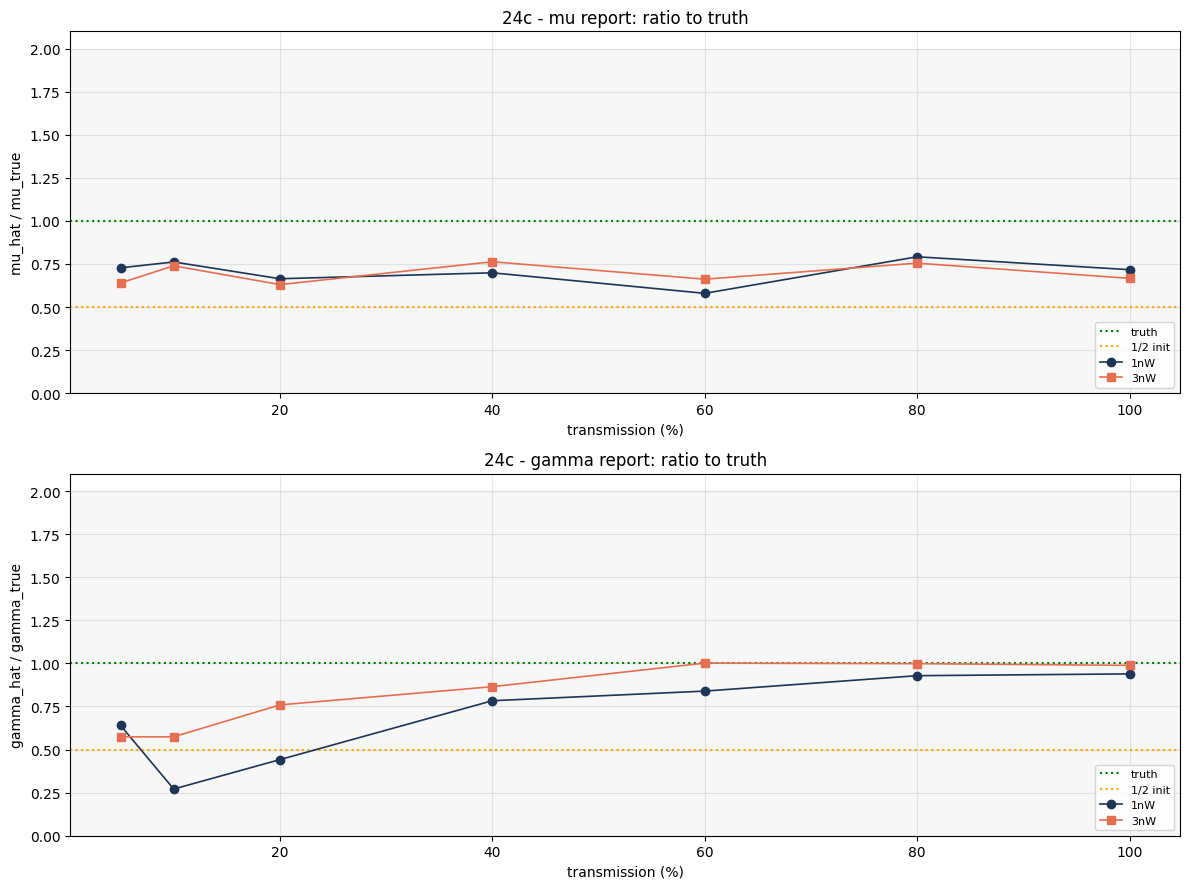

In [15]:
# ============================================================
# FIG 2 — the μ report (top) and the γ report (bottom): ratio to truth ± the Fisher CRB whisker.
#   22a's style; ONE panel per parameter, with the hue = laser power (1nW | 3nW).
#   Whisker = the dataset CRB (B): truth-inside = honesty.
# ============================================================
def _trow(power):
    return sorted([t for t in TABLE if t['exp'].startswith(power)],
                  key=lambda t: int(t['exp'].split('Trans')[-1]))

COL = {'1nW': '#1d3557', '3nW': '#e76f51'}
MK  = {'1nW': 'o-', '3nW': 's-'}
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for ax, key in zip(axes, ['mu', 'gamma']):
    for power in POWERS:
        ts = _trow(power)
        xs = [int(t['exp'].split('Trans')[-1]) for t in ts]
        if key == 'mu':
            ys  = [t['mu'] / t['mu_true'] for t in ts]
            err = [t['sig_mu_data'] / t['mu_true'] for t in ts] if DO_FISHER else None
        else:
            ys  = [t['gamma'] / t['gamma_true'] for t in ts]
            err = [t['sig_g_data'] / t['gamma_true'] for t in ts] if DO_FISHER else None
        ax.errorbar(xs, ys, yerr=err, fmt=MK[power], color=COL[power], capsize=4, ms=6, lw=1.2,
                    label=(f'{power}   (whisker = Fisher sigma_{key})' if DO_FISHER else power))
    ax.axhline(1.0, color='g', ls=':', label='truth')
    ax.axhline(0.5, color='orange', ls=':', label='1/2 init')
    ax.axhspan(0.0, 2.0, color='gray', alpha=0.06)
    ax.set_xlabel('transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true')
    ax.set_ylim(0, 2.1); ax.grid(alpha=0.3); ax.legend(fontsize=8, loc='lower right')
    ax.set_title(f"{NB_ID} - {key} report: ratio to truth" + (" with Fisher sigma whiskers (dataset CRB)" if DO_FISHER else ""))
fig.tight_layout(); plt.show()


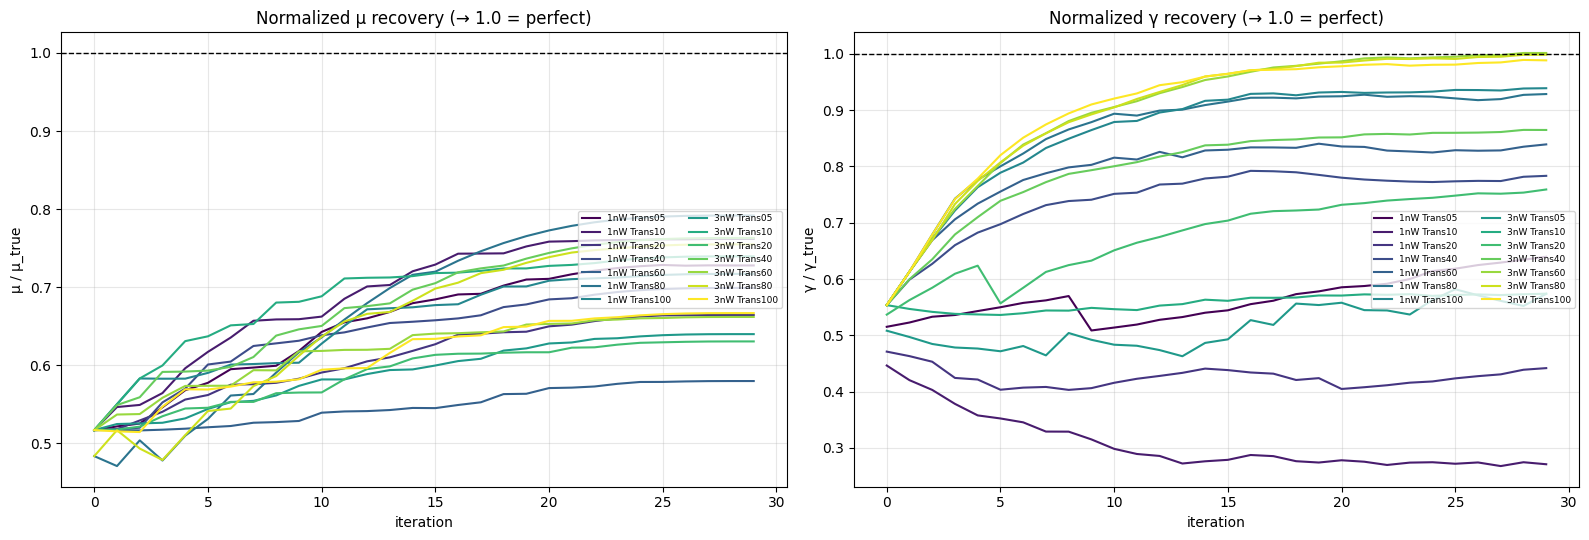

In [16]:
# ============================================================
# FIG 3 — normalized trajectories (μ/μ_true, γ/γ_true vs iteration); starts AT the 0.5x init
#   (22a verbatim)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
colors = plt.cm.viridis(np.linspace(0, 1, len(RESULTS)))
for r, c in zip(RESULTS, colors):
    st = [h['step'] for h in r['history']]
    axes[0].plot(st, [h['mu']    / r['mu_true']    for h in r['history']], color=c, lw=1.5, label=r['exp'])
    axes[1].plot(st, [h['gamma'] / r['gamma_true'] for h in r['history']], color=c, lw=1.5, label=r['exp'])
for ax, yl in [(axes[0], 'μ / μ_true'), (axes[1], 'γ / γ_true')]:
    ax.axhline(1.0, color='k', ls='--', lw=1); ax.set_xlabel('iteration'); ax.set_ylabel(yl); ax.grid(alpha=0.3)
    ax.legend(fontsize=6.5, ncol=2, loc='center right')
axes[0].set_title('Normalized μ recovery (→ 1.0 = perfect)')
axes[1].set_title('Normalized γ recovery (→ 1.0 = perfect)')
plt.tight_layout(); plt.show()


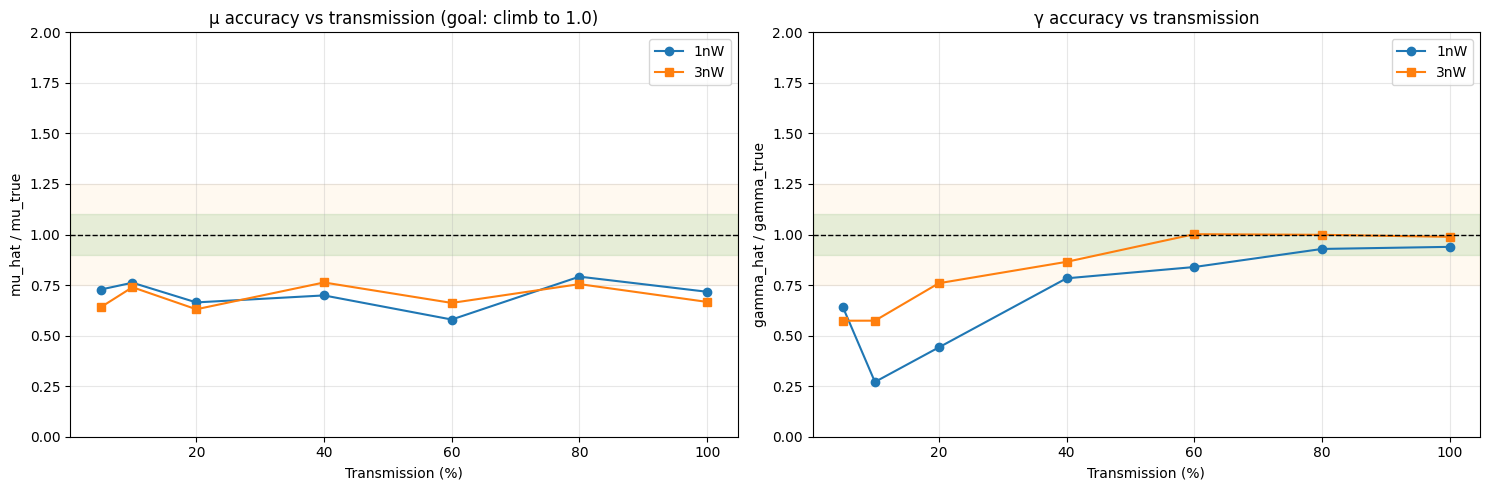

graded-goal check (ratio by transmission):
    T   mu(1nW)   mu(3nW)    g(1nW)    g(3nW)
    5     0.728      0.64      0.64     0.574
   10     0.762     0.739     0.271     0.574
   20     0.664      0.63     0.442     0.759
   40     0.699     0.763     0.783     0.865
   60      0.58     0.662     0.839     1.002
   80     0.792     0.755     0.929     0.999
  100     0.717     0.667     0.939     0.989


In [17]:
# ============================================================
# FIG 4 — accuracy vs transmission (goal: ratios climb toward 1.0 with T)   (22a verbatim)
# ============================================================
pows = ['1nW', '3nW']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, key in zip(axes, ['mu', 'gamma']):
    for p, mk in zip(pows, ['o-', 's-']):
        rs = sorted([r for r in RESULTS if r['power'] == p], key=lambda z: z['T'])
        if not rs: continue
        xs = [r['T'] for r in rs]
        ys = [(r['mu_final']/r['mu_true']) if key == 'mu' else (r['gamma_final']/r['gamma_true']) for r in rs]
        ax.plot(xs, ys, mk, label=p, ms=6)
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.axhspan(0.9, 1.1, color='green', alpha=0.10); ax.axhspan(0.75, 1.25, color='orange', alpha=0.06)
    ax.set_xlabel('Transmission (%)'); ax.set_ylabel(f'{key}_hat / {key}_true'); ax.set_ylim(0, 2.0)
    ax.grid(alpha=0.3); ax.legend()
axes[0].set_title('μ accuracy vs transmission (goal: climb to 1.0)')
axes[1].set_title('γ accuracy vs transmission')
plt.tight_layout(); plt.show()

print('graded-goal check (ratio by transmission):')
print(f"{'T':>5} {'mu(1nW)':>9} {'mu(3nW)':>9} {'g(1nW)':>9} {'g(3nW)':>9}")
for T in sorted({r['T'] for r in RESULTS}):
    row = [T]
    for p in pows:
        rs = [r for r in RESULTS if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['mu_final']/rs[0]['mu_true'], 3) if rs else float('nan'))
    for p in pows:
        rs = [r for r in RESULTS if r['power'] == p and r['T'] == T]
        row.append(round(rs[0]['gamma_final']/rs[0]['gamma_true'], 3) if rs else float('nan'))
    print(f"{row[0]:>5} {row[1]:>9} {row[2]:>9} {row[3]:>9} {row[4]:>9}")


In [18]:
if not DO_FISHER:
    print('DO_FISHER=False - FIG5 (Fisher ellipses) skipped')
else:
    # ============================================================
    # FIG 5 — FISHER ELLIPSES (1σ) in (μ, γ) at the fitted point
    #   21c's FIG 10, laid out as 2 columns (1nW | 3nW) × 7 rows (Trans05…Trans100).
    #   The ellipse is the dataset CRB (B). Variant A (per-scan) is a factor √N larger -> off-panel.
    # ============================================================
    from matplotlib.patches import Ellipse
    fig, axes = plt.subplots(7, 2, figsize=(12, 26))
    for ci, power in enumerate(POWERS):
        ts = _trow(power)
        for ri, t in enumerate(ts):
            ax = axes[ri][ci]
            sm, sg, corr = t['sig_mu_data'], t['sig_g_data'], t['corr']
            degenerate = sg < 1e-6                       # σ_γ → 0: the low-count Fisher degeneracy
            if not degenerate:
                cov = np.array([[sm**2, corr*sm*sg], [corr*sm*sg, sg**2]])
                lam_, vec = np.linalg.eigh(cov)
                ang = np.degrees(np.arctan2(vec[1, -1], vec[0, -1]))
                ax.add_patch(Ellipse((t['mu'], t['gamma']), 2*np.sqrt(lam_[0]), 2*np.sqrt(lam_[1]),
                                     angle=ang, facecolor='#457b9d', edgecolor='k', alpha=0.35, lw=0.8,
                                     label='Fisher CRB (1σ, dataset)'))
            ax.plot(t['mu'], t['gamma'], 'b.', ms=9, label='fit')
            ax.plot(t['mu_true'], t['gamma_true'], 'g*', ms=16, label='truth')
            dg_txt = 'σγ→0 (degenerate)' if degenerate else f"Δγ/σ={t['dg_sigma_data']:.1f}"
            ax.set_title(f"{t['exp']}  |  Δμ/σ={t['dmu_sigma_data']:.1f}   {dg_txt}", fontsize=8)
            ax.set_xlabel('μ (photons)'); ax.set_ylabel('γ (MHz)'); ax.grid(alpha=0.3); ax.legend(fontsize=6)
    plt.suptitle('23a — Fisher CRB ellipses (1σ, dataset) at the fitted point', fontsize=13)
    plt.tight_layout(); plt.show()

DO_FISHER=False - FIG5 (Fisher ellipses) skipped


## Verdict — the cosine shape is a **second-order** lever: at the *same* total travel it costs a little μ (0.0730 → 0.0787) and buys nothing

`W_obj(all14) = 0.0787 | T>=40 0.0505 | T<=20 0.1650 | mu rel-RMSE 30.6 % | gamma rel-RMSE 32.7 % | diverged 0/14`
(vs 24b: 0.0730 / 0.0435 / 0.1633 / 28.0 % / 33.6 % / 0)

**(a) The prediction was *nearly* HIT, and the sign is negative.** The cosine never beats the constant and no
low-T overshoot returns; the objective moves by **+0.0057** — just outside the ±0.005 chaos band. Per cell the
μ ratios fall by 0.00–0.08 (worst: 3nW T80 0.833 → 0.755, 3nW T05 0.683 → 0.640), i.e. the cosine lands
**further from truth**, not closer.

**(b) Why — and the real diagnostic of this notebook.** Recomputing the step accounting from the recorded path
(see the diagnostic cell): the **realised net travel is only 0.16–0.67 × μ_init** for *both* schedules
(24b: 0.22–0.67; 24c: 0.16–0.58), and the per-step **raw** step `lr_mu_eff·|∇μ_k|` has median 0.1–0.7 × the
clip — so the *clip/budget is mostly NOT binding*. The binding constraint is the **LR itself**: `lr_mu_eff`
is calibrated once at the init, where `|∇μ|` is inflated, and `|∇μ_k|` then decays 2–5× over the run. Front-
loading the budget does not help because the budget was never the thing holding the cells back; it only
shrinks the late caps that occasionally do bind (raw step up to ×206 the cap at 3nW T80), which removes a
little useful travel. **The shape of the schedule is a ~8 %-of-objective effect; the travel *rate* is the lever.**

**Prediction: PARTLY HIT.** The pre-registered test was `|ΔW_obj| ≤ 0.005` and per-cell ±0.05; the shape is
indeed a small, second-order effect (no regime reordering, no overshoot), but it lands marginally outside the
band and with a *negative* sign — so "the landing is set only by total travel" is **not exactly true**: the
shape perturbs the landing by a few percent.

**FM tags:** FM#9 (travel/starvation) stays the dominant residual; **new diagnostic FM#13** (recorded in
`SERIES_STATE.md` §4) — *the init-calibrated μ LR under-estimates the post-init `|∇μ|`, so every cell
under-travels (net 0.16–0.67 × μ_init) and the clip is mostly idle*. **Next:** A4 (`24d`, per-cell σ_prop²
budget with a cap/floor) — note this notebook *predicts* A4 will be weak if it only enlarges the cap; the
scale knob should move the **LR**, not the cap (carried to 24e/24h).


## Notes / caveats

- **Chaos band.** The objective is chaotically sensitive (~±0.01 for <1e-3 knob changes; integer photon
  rounding). Treat ≤0.005 differences as noise; repeat a winning config ≥2× before believing it.
- **Truth-free rule.** Every knob derived from data must come from the *target cloud* or the *sim cloud* —
  never from `mu_true`/`gamma_true`. (The protocol init `0.5 × truth` is the single documented exception
  and is a property of the protocol, not a tuned knob.)
- **One change per notebook**, stated in the markdown cell above the config; keep the rest byte-identical
  by **forking the previous notebook** (`cp 24x.ipynb 24y.ipynb`).
- Figures render inline (no `savefig`); FIG1 is exported to HTML for the browser. Run **in place**
  (`papermill 24x.ipynb 24x.ipynb`), never an `-executed` copy.
- Append the log row in `SERIES_STATE.md` §7 and commit+push after every notebook.
